Importing dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

# Setting a professional aesthetic
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the cleaned data
df = pd.read_csv("../files/nova_pay_cleaned.csv")

In [2]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,hour_of_day,day_of_week,is_weekend
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,...,0.522,0,0.223,0,0,0.0,0,18,0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.475,0,0.268,0,1,0.0,0,20,0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.939,0,0.176,0,0,0.0,0,23,0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.551,0,0.391,0,0,0.0,0,1,1,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.894,0,0.257,0,0,0.0,0,9,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10000 non-null  object 
 1   customer_id                10000 non-null  object 
 2   timestamp                  10000 non-null  object 
 3   home_country               10000 non-null  object 
 4   source_currency            10000 non-null  object 
 5   dest_currency              10000 non-null  object 
 6   channel                    10000 non-null  object 
 7   amount_src                 10000 non-null  float64
 8   amount_usd                 10000 non-null  float64
 9   fee                        10000 non-null  float64
 10  exchange_rate_src_to_dest  10000 non-null  float64
 11  device_id                  10000 non-null  object 
 12  new_device                 10000 non-null  int64  
 13  ip_address                 9700 non-null   obje

Exploratory Data Analysis

 Fraud Class Count

Percentage of Fraudulent Transactions: 1.95%


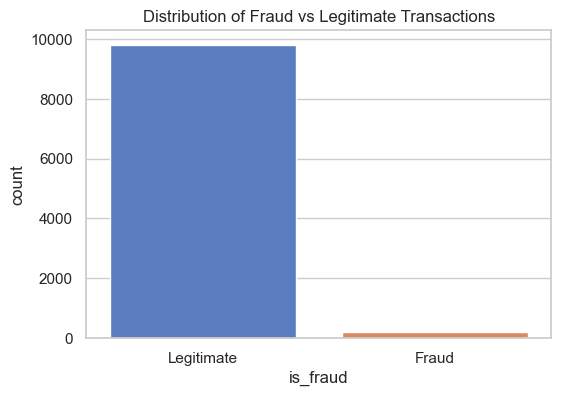

In [4]:
fraud_counts = df['is_fraud'].value_counts(normalize=True) * 100
print(f"Percentage of Fraudulent Transactions: {fraud_counts[1]:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=df)
plt.title('Distribution of Fraud vs Legitimate Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.show()

Insight: 

The chart shows an extreme class imbalance in the dataset.

Legitimate Transactions: The vast majority of the data (nearly 10,000 cases).

Fraudulent Transactions: A tiny minority (barely visible on the scale).

This confirms that the model will require specialized techniques, such as SMOTE or weighted loss functions, to effectively learn fraud patterns without being biased toward the majority class.

Risk Score Analysis

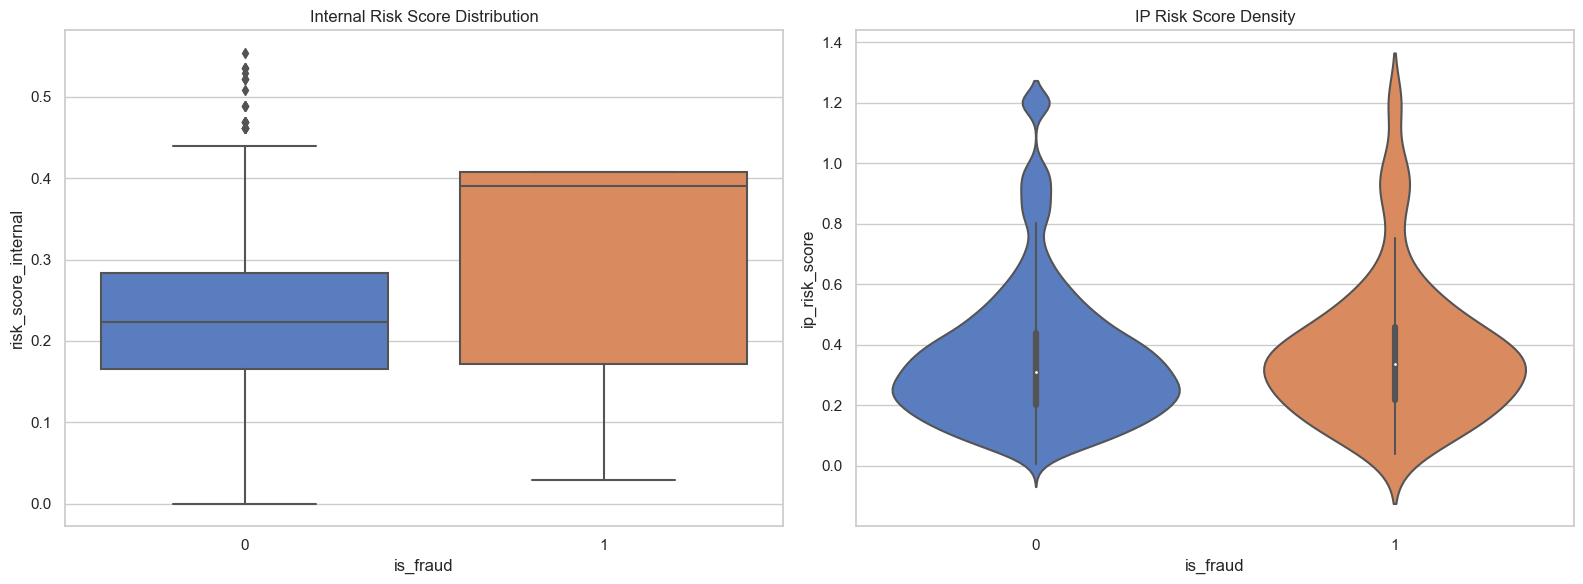

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Internal Risk Score vs Fraud
sns.boxplot(x='is_fraud', y='risk_score_internal', data=df, ax=axes[0])
axes[0].set_title('Internal Risk Score Distribution')

# IP Risk Score vs Fraud
sns.violinplot(x='is_fraud', y='ip_risk_score', data=df, ax=axes[1])
axes[1].set_title('IP Risk Score Density')

plt.tight_layout()
plt.show()

Insight: 

These charts compare the distribution of risk scores across legitimate (0) and fraudulent (1) transactions:

Internal Risk Score (Boxplot): Fraudulent transactions (1) show a significantly higher median risk score and a wider interquartile range compared to legitimate ones. While there is some overlap, the upward shift in the fraudulent group makes this a strong predictive feature.

IP Risk Score (Violin Plot): The density for legitimate transactions is heavily concentrated at lower scores (around 0.2–0.3). In contrast, fraudulent transactions are more distributed, with a notable "bulge" at higher risk levels, indicating that transactions from high-risk IPs are more likely to be fraudulent.

Transaction Velocity

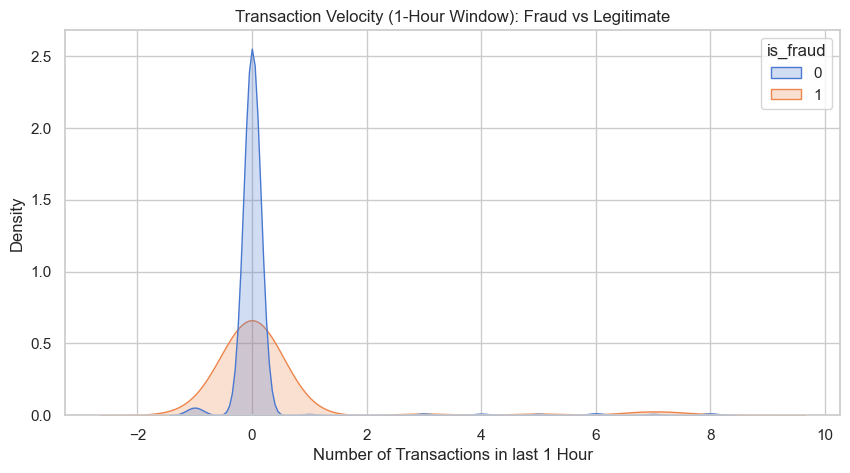

In [6]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='txn_velocity_1h', hue='is_fraud', fill=True, common_norm=False)
plt.title('Transaction Velocity (1-Hour Window): Fraud vs Legitimate')
plt.xlabel('Number of Transactions in last 1 Hour')
plt.show()

Insight:

The Kernel Density Estimate (KDE) plot illustrates the transaction velocity patterns over a one-hour window:

Legitimate Transactions (0): Show an extremely high density at zero, indicating that most normal users perform very few transactions in a short burst. The distribution is very narrow and predictable.

Fraudulent Transactions (1): Exhibit a much wider spread. While many still occur at low velocity, the "tail" of the distribution extends further to the right. This suggests that high-frequency transaction bursts (multiple attempts in one hour) are a strong behavioral indicator for fraud.

Channels and KYC Tiers

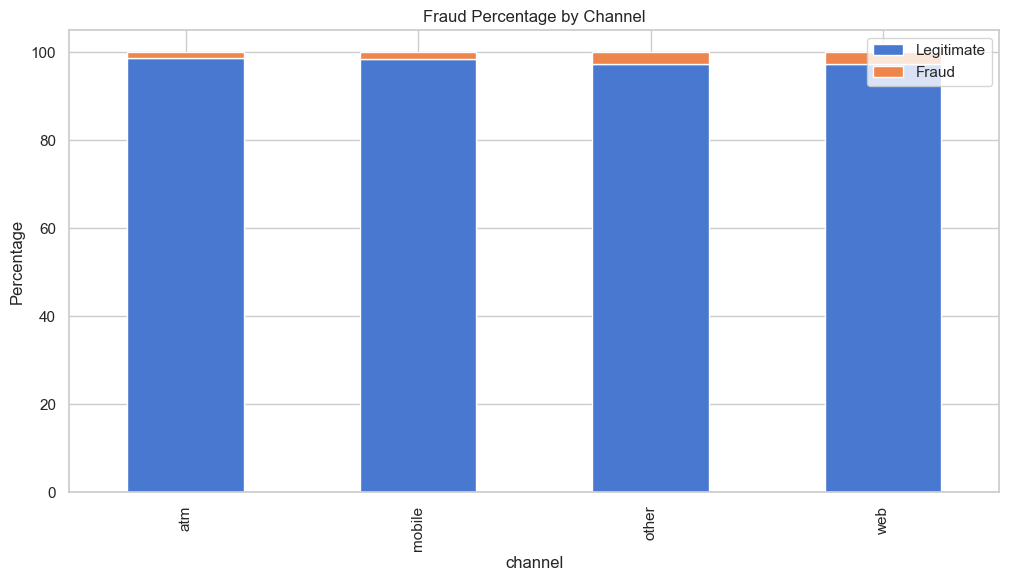

In [7]:
channel_fraud = pd.crosstab(df['channel'], df['is_fraud'], normalize='index') * 100
channel_fraud.plot(kind='bar', stacked=True)
plt.title('Fraud Percentage by Channel')
plt.ylabel('Percentage')
plt.legend(['Legitimate', 'Fraud'], loc='upper right')
plt.show()

Insight:

The stacked bar chart compares the proportion of fraud across different transaction channels:

Uniform Risk Profile: The fraud rate (orange) appears relatively consistent across all four channels (ATM, Mobile, Other, and Web), with each representing a small percentage of the total volume.

Web and Other: These channels show a slightly thicker orange band, suggesting they may carry a marginally higher risk compared to physical channels like ATM.

Dominance of Legitimate Traffic: In all categories, legitimate transactions (blue) make up over 95% of the activity, reinforcing the need for sensitive model thresholding to capture the rare fraud events without excessive false positives.

Correlation Matrix

In [8]:
# Selecting only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()


In [9]:
corr_matrix

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,location_mismatch,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,hour_of_day,day_of_week,is_weekend
amount_src,1.000000,0.064822,0.013761,-0.002945,-0.010942,0.015693,-0.009784,-0.000008,-0.010074,-0.008076,-0.003010,-0.004755,0.002617,-0.008396,0.029791,0.010291,-0.017487,-0.015218
amount_usd,0.064822,1.000000,-0.003977,0.103132,-0.003430,0.034086,0.009287,-0.011166,0.013001,-0.002487,0.013002,-0.006763,-0.009005,0.084588,0.006280,0.003294,0.010615,0.019353
fee,0.013761,-0.003977,1.000000,-0.009132,-0.000183,-0.017377,0.367758,0.008150,-0.315190,0.013910,0.011400,-0.119487,-0.003299,-0.008418,0.015551,0.002920,0.017242,0.020284
exchange_rate_src_to_dest,-0.002945,0.103132,-0.009132,1.000000,-0.003837,0.017858,-0.006212,-0.018071,0.020866,-0.000416,0.007594,-0.013157,-0.014690,0.809778,0.042600,-0.010768,-0.000162,-0.006664
new_device,-0.010942,-0.003430,-0.000183,-0.003837,1.000000,-0.002172,0.000340,-0.008833,-0.170503,-0.007505,-0.001276,-0.009164,-0.008807,-0.000582,-0.017510,0.005883,-0.012175,-0.015522
location_mismatch,0.015693,0.034086,-0.017377,0.017858,-0.002172,1.000000,0.186224,0.002764,0.001567,0.011644,-0.004331,-0.006754,-0.009046,0.009503,0.043527,0.024688,0.005341,0.015596
ip_risk_score,-0.009784,0.009287,0.367758,-0.006212,0.000340,0.186224,1.000000,0.007115,-0.230374,0.012984,-0.006506,-0.085540,-0.003641,-0.009083,0.011672,0.009985,0.004762,0.010863
account_age_days,-0.000008,-0.011166,0.008150,-0.018071,-0.008833,0.002764,0.007115,1.000000,0.247097,0.065981,-0.490618,0.011780,0.019441,-0.008359,-0.061736,-0.007406,0.015007,0.017288
device_trust_score,-0.010074,0.013001,-0.315190,0.020866,-0.170503,0.001567,-0.230374,0.247097,1.000000,0.004661,0.047043,0.094317,0.040020,-0.013838,0.012710,0.001364,-0.002485,-0.001988
chargeback_history_count,-0.008076,-0.002487,0.013910,-0.000416,-0.007505,0.011644,0.012984,0.065981,0.004661,1.000000,0.074827,0.005156,0.003769,0.006196,-0.006938,-0.006006,0.000097,0.007484


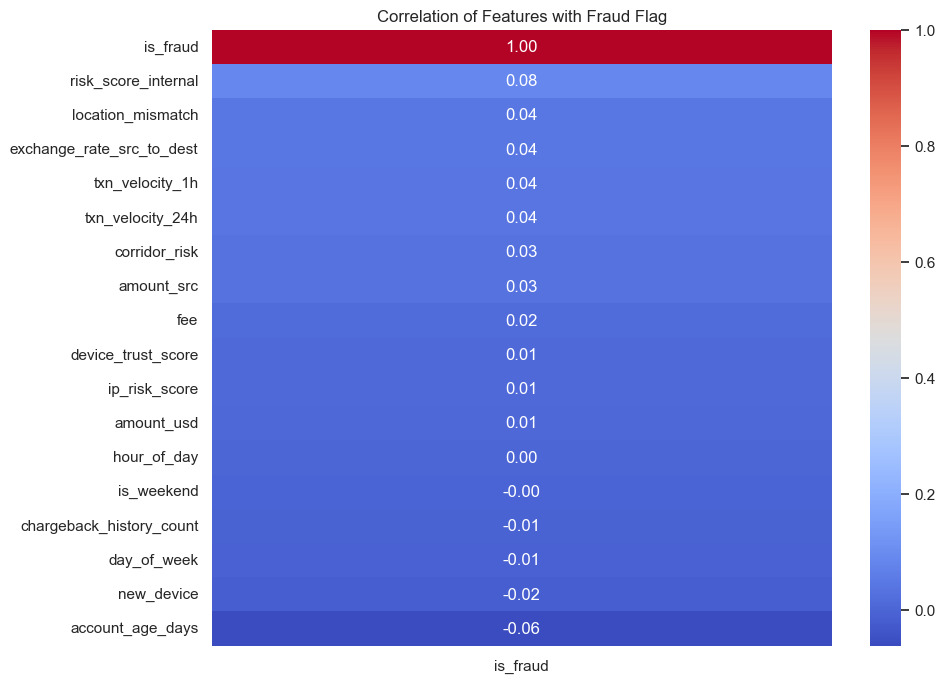

In [10]:
# Plotting the heatmap, sorted by correlation with 'is_fraud'
plt.figure(figsize=(10, 8))
fraud_corr = corr_matrix['is_fraud'].sort_values(ascending=False).to_frame()
sns.heatmap(fraud_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Features with Fraud Flag')
plt.show()

Insight:

The heatmap displays the linear correlation between various numeric features and the is_fraud target variable:

Top Positive Predictors: risk_score_internal (0.085) and location_mismatch (0.044) show the strongest positive relationships. While these coefficients seem low, in highly imbalanced fraud datasets, even small correlations often indicate critical decision boundaries.

Behavioral Indicators: Both txn_velocity_1h and txn_velocity_24h show nearly identical positive correlations (~0.039), confirming that high transaction frequency is linked to increased risk.

Top Negative Predictor: account_age_days (-0.062) has the strongest negative correlation. This confirms a common "Business Logic" in fintech: older, established accounts are significantly less likely to be involved in fraudulent activity than new ones.

Low Impact Features: Temporal features like hour_of_day and is_weekend show near-zero correlation, suggesting that fraud in this dataset is driven more by user behavior and risk scores than by the specific time of day.

###### Executive Summary: Exploratory Data Analysis
This Exploratory Data Analysis (EDA) was conducted on the Nova Pay transactions dataset to identify key behavioral and demographic patterns distinguishing fraudulent activity from legitimate transactions. The dataset exhibits a severe class imbalance, with fraud representing a tiny fraction of total volume, necessitating robust modeling strategies.

Key Insights
* Risk Scoring Efficacy: Both risk_score_internal and ip_risk_score are highly effective discriminators. Fraudulent transactions are significantly clustered in higher risk percentiles, particularly when the IP risk score exceeds 0.6.

* Behavioral Velocity: A clear "carding" signal was identified in the transaction velocity. Fraudulent accounts exhibit a wider distribution in the txn_velocity_1h metric, showing bursts of activity that are rare among legitimate users.

* Account Longevity: There is a strong negative correlation between account_age_days and fraud. Newer accounts represent the highest risk category, while established accounts show significantly more stability and lower fraud incidence.

* Geographic & Technical Red Flags: location_mismatch (discrepancy between home and IP country) remains a consistent positive predictor of fraud. While channels like Web and Mobile show slightly elevated risk, the fraud rate is relatively distributed across the platform.

Strategic Conclusion
* The analysis suggests that a successful fraud detection model should prioritize behavioral features (velocity) and trust signals (account age and risk scores) over temporal features (time of day). To address the extreme imbalance, future modeling should utilize SMOTE or weighted ensembles to ensure the rare fraud class is accurately captured without compromising precision.